In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 300

df = pd.DataFrame({
    'temp': np.random.normal(20, 8, n).round(1),
    'humidity': np.random.randint(20, 100, n),
    'windspeed': np.random.normal(15, 7, n).round(1),
    'season': np.random.choice(['봄', '여름', '가을', '겨울'], n),
    'holiday': np.random.choice(['Yes', 'No'], n, p=[0.1, 0.9]),
    'hour': np.random.randint(0, 24, n),
    'rentals': np.random.poisson(150, n)
})

df.loc[np.random.choice(n, 20, replace=False), 'temp'] = np.nan
df.loc[np.random.choice(n, 10, replace=False), 'windspeed'] = np.random.uniform(60, 100, 10)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   temp       280 non-null    float64
 1   humidity   300 non-null    int32  
 2   windspeed  300 non-null    float64
 3   season     300 non-null    object 
 4   holiday    300 non-null    object 
 5   hour       300 non-null    int32  
 6   rentals    300 non-null    int32  
dtypes: float64(2), int32(3), object(2)
memory usage: 13.0+ KB


In [5]:
df.isna().sum()

temp         20
humidity      0
windspeed     0
season        0
holiday       0
hour          0
rentals       0
dtype: int64

EDA/시각화 (10점)
seaborn boxplot으로 season별 rentals 분포를 시각화하세요 (x=season, y=rentals)

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm

font_path = 'C:\\Windows\\Fonts\\malgun.ttf'
font = fm.FontProperties(fname=font_path).get_name()
mpl.rc('font', family=font)
mpl.rcParams['axes.unicode_minus'] = False

<Axes: xlabel='season', ylabel='rentals'>

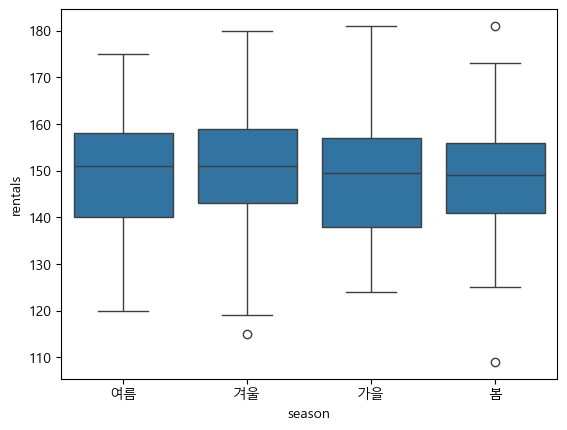

In [13]:
sns.boxplot(data = df, x = 'season', y = 'rentals')

### 전처리 (30점)
temp 결측치는 평균으로 대체
windspeed는 IQR 방법으로 이상치 탐지 후 상한 capping
season, holiday를 원-핫 인코딩하여 df_enc에 저장
temp, humidity, windspeed, hour를 StandardScaler로 스케일링

In [14]:
df.isna().sum()

temp         20
humidity      0
windspeed     0
season        0
holiday       0
hour          0
rentals       0
dtype: int64

In [15]:
df['temp'] = df['temp'].fillna(df['temp'].mean())

In [16]:
q1 = df['windspeed'].quantile(0.25)
q3 = df['windspeed'].quantile(0.75)

In [17]:
iqr = q3 - q1

In [18]:
upper_bound = q1 - (1.5 * iqr)

In [22]:
df.loc[df['windspeed'] > upper_bound, 'windspeed'] = upper_bound

In [26]:
df_enc = pd.get_dummies(data = df, columns = ['season', 'holiday'])

In [27]:
df_enc

,temp,humidity,windspeed,hour,rentals,season_가을,season_겨울,season_봄,season_여름,holiday_No,holiday_Yes
0,24.0,55,-6.3,16,151,False,False,False,True,True,False
1,18.9,29,-6.3,7,151,False,True,False,False,True,False
2,25.2,92,-6.3,14,130,False,True,False,False,True,False
3,32.2,43,-6.3,7,134,True,False,False,False,True,False
4,18.1,83,-6.3,16,161,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
295,14.5,98,-6.3,21,154,True,False,False,False,True,False
296,27.2,66,-6.3,4,163,True,False,False,False,True,False
297,22.5,75,-6.3,19,155,False,True,False,False,True,False
298,26.5,33,-6.3,7,141,False,False,True,False,True,False


In [29]:
from sklearn.preprocessing import StandardScaler

In [36]:
ss = StandardScaler()

In [37]:
cols = ['temp', 'humidity', 'windspeed', 'hour']

In [38]:
df_enc[cols] = ss.fit_transform(df_enc[cols])

### 3. 머신러닝 (30점)
- rentals를 y, 나머지를 X로 하여 train/test 8:2 분할 (random_state=42, 변수명 X_train, X_valid, y_train, y_valid)
- RandomForestRegressor(max_depth=5, random_state=42)로 학습 후 검증셋 MAE 산출

In [40]:
y = df_enc['rentals']

In [41]:
X = df_enc.drop(columns = 'rentals', axis = 1)

In [42]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

In [46]:
from sklearn.ensemble import RandomForestRegressor

In [47]:
rfr = RandomForestRegressor(max_depth = 5, random_state = 42)

In [48]:
rfr.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [49]:
from sklearn.metrics import mean_absolute_error

In [51]:
y_pred = rfr.predict(X_test)

In [52]:
mae = mean_absolute_error(y_test, y_pred)

In [53]:
print('mae: ' , mae)

mae:  10.163129020406068


### 딥러닝 (30점)
- Sequential 모델: Dense(64, relu) → Dense(32, relu) → Dense(1, linear)
- optimizer='adam', loss='mse'
- EarlyStopping(monitor='val_loss', patience=5) 적용
- epochs=50, batch_size=32로 학습 (validation_data=(X_valid, y_valid)), history 변수에 저장

In [54]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

In [56]:
model_dl = Sequential([
    Input(shape = (X_train.shape[1],)),
    Dense(64, activation = 'relu'),
    Dense(32, activation = 'relu'),
    Dense(1, activation = 'linear')
])

In [57]:
model_dl.compile(
    optimizer = 'adam',
    loss = 'mse'
)

In [58]:
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 5
)

In [59]:
history = model_dl.fit(
    X_train, y_train,
    validation_data = (X_test, y_test),
)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 22478.6191 - val_loss: 22553.9570
